In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
import copy
import seaborn as sns

In [9]:
df_d = pd.read_csv("Dutch_paydiff_norm.csv")
df_h = pd.read_csv("Honolulu_paydiff_norm.csv")
df_d = df_d[df_d["subsession.round_number"] > 2]
df_h = df_h[df_h["subsession.round_number"] > 2]

In [10]:
# info dict of each auction
dict_all = dict()
for index, row in df_d.iterrows():
    key = (row["session.code"], row["subsession.round_number"], row["group.id_in_subsession"])

    if key not in dict_all:
        dict_all[key] = {
            "session_name": row["session.config.name"],
            "discount": row["session.config.discount_b"],
            "d_dutch_final_price": row["group.dutch_final_price"],
            "d_item_value": [],
            "d_dutch_winner_item_value": 0,
            "d_dutch_winner_value_rank": 0,
            "d_dutch_winner_optimal_bid": 0,
            "h_dutch_final_price": None,
            "h_item_value": [],
            "h_dutch_winner_item_value": 0,
            "h_dutch_winner_value_rank": 0,
            "h_dutch_winner_optimal_bid": 0,
            "h_contest_leave_item_value": [],
            "h_english_num_player": 0,
            "h_english_leave_item_value": [],
            "h_english_leave_price": [],
        }

    dict_all[key]["d_item_value"].append(row["player.item_value"])
    
    if row["player.is_dutch_winner"] == 1:
        dict_all[key]["d_dutch_winner_item_value"] = row["player.item_value"]
        dict_all[key]["d_dutch_winner_optimal_bid"] = row["predict.player.bid"]

tmp_dict = dict()
for index, row in df_h.iterrows():
    key = (row["session.code"], row["subsession.round_number"], row["group.id_in_subsession"])

    if dict_all[key]["h_dutch_final_price"] == None:
        dict_all[key]["h_dutch_final_price"] = row["group.dutch_final_price"]
        
    dict_all[key]["h_item_value"].append(row["player.item_value"])

    if row["player.is_dutch_winner"] == 1:
        dict_all[key]["h_dutch_winner_item_value"] = row["player.item_value"]
        dict_all[key]["h_dutch_winner_optimal_bid"] = row["predict.player.optimal_dutch_bid"]

    dict_all[key]["h_english_num_player"] = row["group.have_contest_winner"]

    if row["player.contest_status"] != 1:
        dict_all[key]["h_contest_leave_item_value"].append(row["player.item_value"])
    elif (dict_all[key]["h_english_num_player"] > 1) and (row["player.is_english_winner"] == 0):
        dict_all[key]["h_english_leave_item_value"].append(row["player.item_value"])
        dict_all[key]["h_english_leave_price"].append(row["player.dropout_price"])

for key in dict_all.keys():
    tmp_list = dict_all[key]["d_item_value"]
    tmp_val = dict_all[key]["d_dutch_winner_item_value"]
    tmp_rank = 1
    for val in tmp_list:
        if val > tmp_val:
            tmp_rank += 1
    dict_all[key]["d_dutch_winner_value_rank"] = tmp_rank

    tmp_list = dict_all[key]["h_item_value"]
    tmp_val = dict_all[key]["h_dutch_winner_item_value"]
    tmp_rank = 1
    for val in tmp_list:
        if val > tmp_val:
            tmp_rank += 1
    dict_all[key]["h_dutch_winner_value_rank"] = tmp_rank

In [11]:
# compute average round payoff for each player

# dutch auction
tmp = dict()
for p_code in set(df_d["participant.code"]):
    tmp[p_code] = np.sum(df_d[df_d["participant.code"] == p_code]["predict.player.payoff"])
df_d["predict.round_payoff"] = df_d["participant.code"].map(tmp) / df_d["session.config.num_formal_rounds"]

# honolulu auction
tmp = dict()
for p_code in set(df_h["participant.code"]):
    tmp[p_code] = np.sum(df_h[df_h["participant.code"] == p_code]["predict.player.payoff"])
df_h["predict.round_payoff"] = df_h["participant.code"].map(tmp) / df_h["session.config.num_formal_rounds"]

In [12]:
# dicts for matching participants to their normalised payoffs

# dutch auction
d_dict_paydiff_norm = {
    (5, 0.019): dict(),
    (5, 0.009): dict(),
    (2, 0.019): dict(),
    (2, 0.009): dict(),
}
d_dict_paydiff_pct = {
    (5, 0.019): dict(),
    (5, 0.009): dict(),
    (2, 0.019): dict(),
    (2, 0.009): dict(),
}
for index, row in df_d.iterrows():
    key = (int(row["session.config.name"][1]), row["session.config.discount_b"])
    d_dict_paydiff_norm[key][row["participant.code"]] = row["paydiff_norm"]
    d_dict_paydiff_pct[key][row["participant.code"]] = row["paydiff_pct"]

# honolulu auction
h_dict_paydiff_norm = {
    (5, 0.019): dict(),
    (5, 0.009): dict(),
    (2, 0.019): dict(),
    (2, 0.009): dict(),
}
h_dict_paydiff_pct = {
    (5, 0.019): dict(), 
    (5, 0.009): dict(),
    (2, 0.019): dict(),
    (2, 0.009): dict(),
}
for index, row in df_h.iterrows():
    key = (int(row["session.config.name"][1]), row["session.config.discount_b"])
    h_dict_paydiff_norm[key][row["participant.code"]] = row["paydiff_norm"]
    h_dict_paydiff_pct[key][row["participant.code"]] = row["paydiff_pct"]

#### Clustering Based On Similarity

In [13]:
def computeBetaDutch(pcode):
    tmpdf = df_h[(df_h["participant.code"] == pcode)]
    model = LogisticRegression()
    x = (tmpdf["predict.player.optimal_dutch_bid"] - tmpdf["group.dutch_final_price"]).tolist()
    y = tmpdf["player.is_dutch_winner"].tolist()
    if (np.sum(y) == 0) or (np.sum(y) == len(y)):
        return np.nan
    else:
        model.fit(np.reshape(x, (-1, 1)), y)
        return model.coef_[0]
    
def computeBetaContest(pcode):
    tmpdf = df_h[(df_h["participant.code"] == pcode)]
    model = LogisticRegression()
    x = (tmpdf["player.item_value"] - tmpdf["group.dutch_final_price"]).tolist()
    y = tmpdf["player.contest_status"].replace(2, 0).tolist()
    if (np.sum(y) == 0) or (np.sum(y) == len(y)):
        return np.nan
    else:
        model.fit(np.reshape(x, (-1, 1)), y)
        return model.coef_[0]
    
def computeBetaEnglish(pcode):
    tmpdf = df_h[(df_h["participant.code"] == pcode) & (df_h["player.contest_status"] == 1)]
    model = LinearRegression()
    x = tmpdf["predict.player.dropout_price"].tolist()
    y = tmpdf["player.dropout_price"].tolist()
    model.fit(np.reshape(x, (-1, 1)), y)
    return model.coef_[0]

def computeBetaDropout(pcode):
    tmp = df_h[(df_h["participant.code"] == pcode)]
    tmp1 = tmp[(tmp["player.contest_status"] != 1)] # contest drop
    tmp2 = tmp[(tmp["player.contest_status"] == 1) & (tmp["player.is_final_winner"] == 0)] # english drop
    tmp3 = tmp[(tmp["group.have_contest_winner"] > 1) & (tmp["player.is_final_winner"] == 1)] # english win
    tmp4 = tmp[(tmp["group.have_contest_winner"] == 1) & (tmp["player.is_final_winner"] == 1)] # dutch direct win
    n1 = np.sum(tmp1["player.dropout_price"] >= (tmp1["player.item_value"] - 2))
    n2 = np.sum(abs(tmp2["player.dropout_price"] - tmp2["player.item_value"]) <= 2)
    n3 = np.sum(tmp3["player.dropout_price"] <= (tmp3["player.item_value"] + 2))
    n4 = np.sum(tmp4["player.dropout_price"] >= (tmp4["player.item_value"] - 2))
    return (n1 + n2 + n3) / (len(tmp) - len(tmp4))
    # return (n1 + n2 + n3 + n4) / len(tmp)

In [14]:
dict_pinfo = dict()
for index, row in df_h.iterrows():
    key = row["participant.code"]
    if key not in dict_pinfo.keys():
        dict_pinfo[key] = {
            "n": int(row["session.config.name"][1]),
            "b": row["session.config.discount_b"],
            "predict.round_payoff": row["predict.round_payoff"],
        }
df_cluster = pd.DataFrame(set(df_h["participant.code"]), columns=["pcode"])
df_cluster["n"] = df_cluster["pcode"].map(lambda x: dict_pinfo[x]["n"])
df_cluster["b"] = df_cluster["pcode"].map(lambda x: dict_pinfo[x]["b"])
df_cluster["predict.round_payoff"] = df_cluster["pcode"].map(lambda x: dict_pinfo[x]["predict.round_payoff"])
df_cluster["paydiff_norm"] = df_cluster.apply(lambda x: h_dict_paydiff_norm[(x["n"], x["b"])][x["pcode"]], axis=1)
df_cluster["paydiff_pct"] = df_cluster.apply(lambda x: h_dict_paydiff_pct[(x["n"], x["b"])][x["pcode"]], axis=1)
df_cluster["paydiff"] = df_cluster.apply(lambda x: h_dict_paydiff_norm[(x["n"], x["b"])][x["pcode"]], axis=1) # paydiff_norm or paydiff_pct
df_cluster["beta_dutch"] = df_cluster["pcode"].map(computeBetaDutch).astype("float64")
df_cluster["beta_contest"] = df_cluster["pcode"].map(computeBetaContest).astype("float64")
df_cluster["beta"] = df_cluster["pcode"].map(computeBetaEnglish).astype("float64")
df_cluster["beta_dropout"] = df_cluster["pcode"].map(computeBetaDropout).astype("float64")

# df_cluster = df_cluster[df_cluster["beta_dutch"].notnull() & df_cluster["beta_contest"].notnull()] # drop invalid regressions
# df_cluster = df_cluster[df_cluster["beta_dropout"].notnull()]

In [15]:
df_h_cluster = pd.DataFrame(set(df_h["participant.code"]), columns=["pcode"])
df_h_cluster["n"] = df_h_cluster["pcode"].map(lambda x: dict_pinfo[x]["n"])
df_h_cluster["b"] = df_h_cluster["pcode"].map(lambda x: dict_pinfo[x]["b"])
df_h_cluster["paydiff_norm"] = df_h_cluster.apply(lambda x: h_dict_paydiff_norm[(x["n"], x["b"])][x["pcode"]], axis=1)
df_h_cluster["paydiff_pct"] = df_h_cluster.apply(lambda x: h_dict_paydiff_pct[(x["n"], x["b"])][x["pcode"]], axis=1)

df_d_cluster = pd.DataFrame(set(df_d["participant.code"]), columns=["pcode"])
df_d_cluster["n"] = df_d_cluster["pcode"].map(lambda x: dict_pinfo[x]["n"])
df_d_cluster["b"] = df_d_cluster["pcode"].map(lambda x: dict_pinfo[x]["b"])
df_d_cluster["paydiff_norm"] = df_d_cluster.apply(lambda x: d_dict_paydiff_norm[(x["n"], x["b"])][x["pcode"]], axis=1)
df_d_cluster["paydiff_pct"] = df_d_cluster.apply(lambda x: d_dict_paydiff_pct[(x["n"], x["b"])][x["pcode"]], axis=1)

##### K-means

In [54]:
def kmeansSS(n, b, k):
    tmpdf = copy.deepcopy(df_cluster[(df_cluster["n"] == n) & (df_cluster["b"] == b)])
    model = KMeans(n_clusters=k, n_init=30)
    model.fit(tmpdf[["paydiff", "beta_dropout"]].values.tolist()) # dropout decision
    # model.fit(tmpdf[["paydiff", "beta"]].values.tolist()) # english stage only
    # model.fit(tmpdf[["paydiff", "beta_dutch", "beta_contest", "beta"]].values.tolist()) # all stages
    return model.inertia_
def kmeanElbow(n, b, kmax):
    x = np.arange(1, kmax + 1)
    y = list(map(lambda t: kmeansSS(n, b, t), x))
    plt.plot(x, y, marker="o")

In [55]:
# def plotCluster(n, b, k):
#     tmpdf = copy.deepcopy(df_cluster[(df_cluster["n"] == n) & (df_cluster["b"] == b)])
#     if n == 2:
#         if b == 0.019:
#             tmpdf["paydiff"] /= 5.88
#         elif b == 0.009:
#             tmpdf["paydiff"] /= 7.26
#     elif n == 5:
#         if b == 0.019:
#             tmpdf["paydiff"] /= 1.265
#         elif b == 0.009:
#             tmpdf["paydiff"] /= 1.445
#     model_cluster = KMeans(n_clusters=k, n_init=30)
#     model_cluster.fit(tmpdf[["paydiff", "beta_dutch", "beta_contest", "beta"]].values.tolist())
#     tmpdf["type"] = model_cluster.labels_
#     plt.figure(figsize=(8, 6))
#     color_list = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
#     for i in range(k):
#         tmpdf2 = tmpdf[tmpdf["type"] == i]
#         plt.scatter(tmpdf2["beta"], tmpdf2["paydiff"], marker="o", s=10, color=color_list[i])
#         plt.scatter(model_cluster.cluster_centers_[i][3], model_cluster.cluster_centers_[i][0], marker="x", s=50, color=color_list[i])
#         print((model_cluster.cluster_centers_[i], sum(model_cluster.labels_ == i)))
#     plt.xlabel("beta")
#     plt.ylabel("paydiff")
#     plt.ylim(-1, 0.4)
#     plt.xlim(0, 1.4)
#     plt.title("HA English stage clustering, n=%d, b=%.3f" % (n, b))

def plotCluster(n, b, k):
    tmpdf = copy.deepcopy(df_cluster[(df_cluster["n"] == n) & (df_cluster["b"] == b)])
    model_cluster = KMeans(n_clusters=k, n_init=30)
    model_cluster.fit(tmpdf[["paydiff", "beta_dropout"]].values.tolist()) # dropout decision
    # model_cluster.fit(tmpdf[["paydiff", "beta"]].values.tolist()) # english stage only
    # model_cluster.fit(tmpdf[["paydiff", "beta_dutch", "beta_contest", "beta"]].values.tolist()) # all stages
    tmpdf["type"] = model_cluster.labels_
    
    label_list = [[i, model_cluster.cluster_centers_[i]] for i in range(k)]
    sorted_labels = [i[0] for i in sorted(label_list, key=lambda x: x[1][0], reverse=True)]
    color_list = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    marker_list = ["o", "v", "d", "*", "s"]
    for i in range(k):
        si = sorted_labels[i]
        tmpdf2 = tmpdf[tmpdf["type"] == si]
        plt.scatter(tmpdf2["beta_dropout"], tmpdf2["paydiff"], marker=marker_list[i], s=10, color=color_list[i]) # dropout decision 
        # plt.scatter(tmpdf2["beta"], tmpdf2["paydiff"], marker="o", s=10, color=color_list[i]) # english stage only
        plt.scatter(model_cluster.cluster_centers_[si][1], model_cluster.cluster_centers_[si][0], marker="x", s=50, color=color_list[i]) # single beta
        # plt.scatter(model_cluster.cluster_centers_[i][3], model_cluster.cluster_centers_[i][0], marker="x", s=50, color=color_list[i]) # all stages multiple beta
        print((np.average(tmpdf2["predict.round_payoff"]), model_cluster.cluster_centers_[si], sum(model_cluster.labels_ == si)))
    
    plt.xlabel("share of optimal decisions")
    plt.ylabel("normalized payoff")
    plt.xlim(0, 1.05)
    plt.title("Treatment " + str(n) + ("H" if b == 0.019 else "L"), pad=10)

pred_pay	[paydiff  beta]  count
(1.12105989676449, array([-0.08347486,  0.95069678]), 28)
(1.3230609964454534, array([-0.61965964,  0.77189709]), 14)
(1.9587631819866667, array([-1.34542985,  0.82560606]), 3)


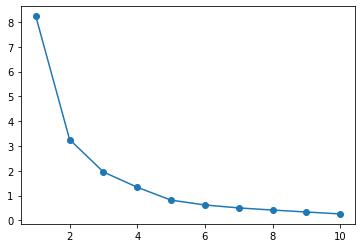

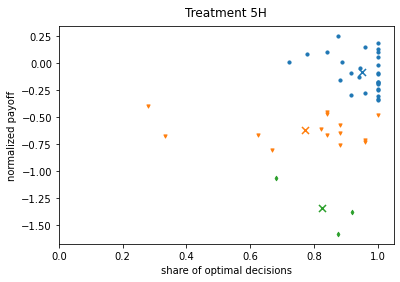

In [56]:
kmeanElbow(5, 0.019, 10)
print("pred_pay\t[paydiff  beta]  count")
plt.figure()
plotCluster(5, 0.019, 3)

In [ ]:
kmeanElbow(5, 0.009, 10)
print("\t[paydiff  beta]  count")
plt.figure()
plotCluster(5, 0.009, 4)

In [ ]:
kmeanElbow(2, 0.019, 10)
print("\t[paydiff  beta]  count")
plt.figure()
plotCluster(2, 0.019, 3)

In [ ]:
kmeanElbow(2, 0.009, 10)
print("\t[paydiff  beta]  count")
plt.figure()
plotCluster(2, 0.009, 3)

(4.924942161876544, array([0.35592204, 0.89007973]), 18)
(6.5838332325185185, array([-1.4850678 ,  0.84206085]), 18)
(6.684381126249999, array([-4.19827002,  0.43665224]), 4)
(7.188449556910257, array([1.03377267, 0.82876625]), 13)
(6.903778773025462, array([-0.18618618,  0.86633605]), 24)
(6.6394537771666675, array([-4.30612044,  0.5       ]), 1)
(1.1210598967644898, array([-0.08347486,  0.95069678]), 28)
(1.3230609964454536, array([-0.61965964,  0.77189709]), 14)
(1.9587631819866667, array([-1.34542985,  0.82560606]), 3)
(1.1736045064309526, array([0.36210978, 0.95634242]), 15)
(1.7806673870565477, array([-0.03959596,  0.89854396]), 12)
(2.513095635184524, array([-0.62619087,  0.90867928]), 6)
(1.3047964236071428, array([-1.46551071,  0.59340659]), 2)


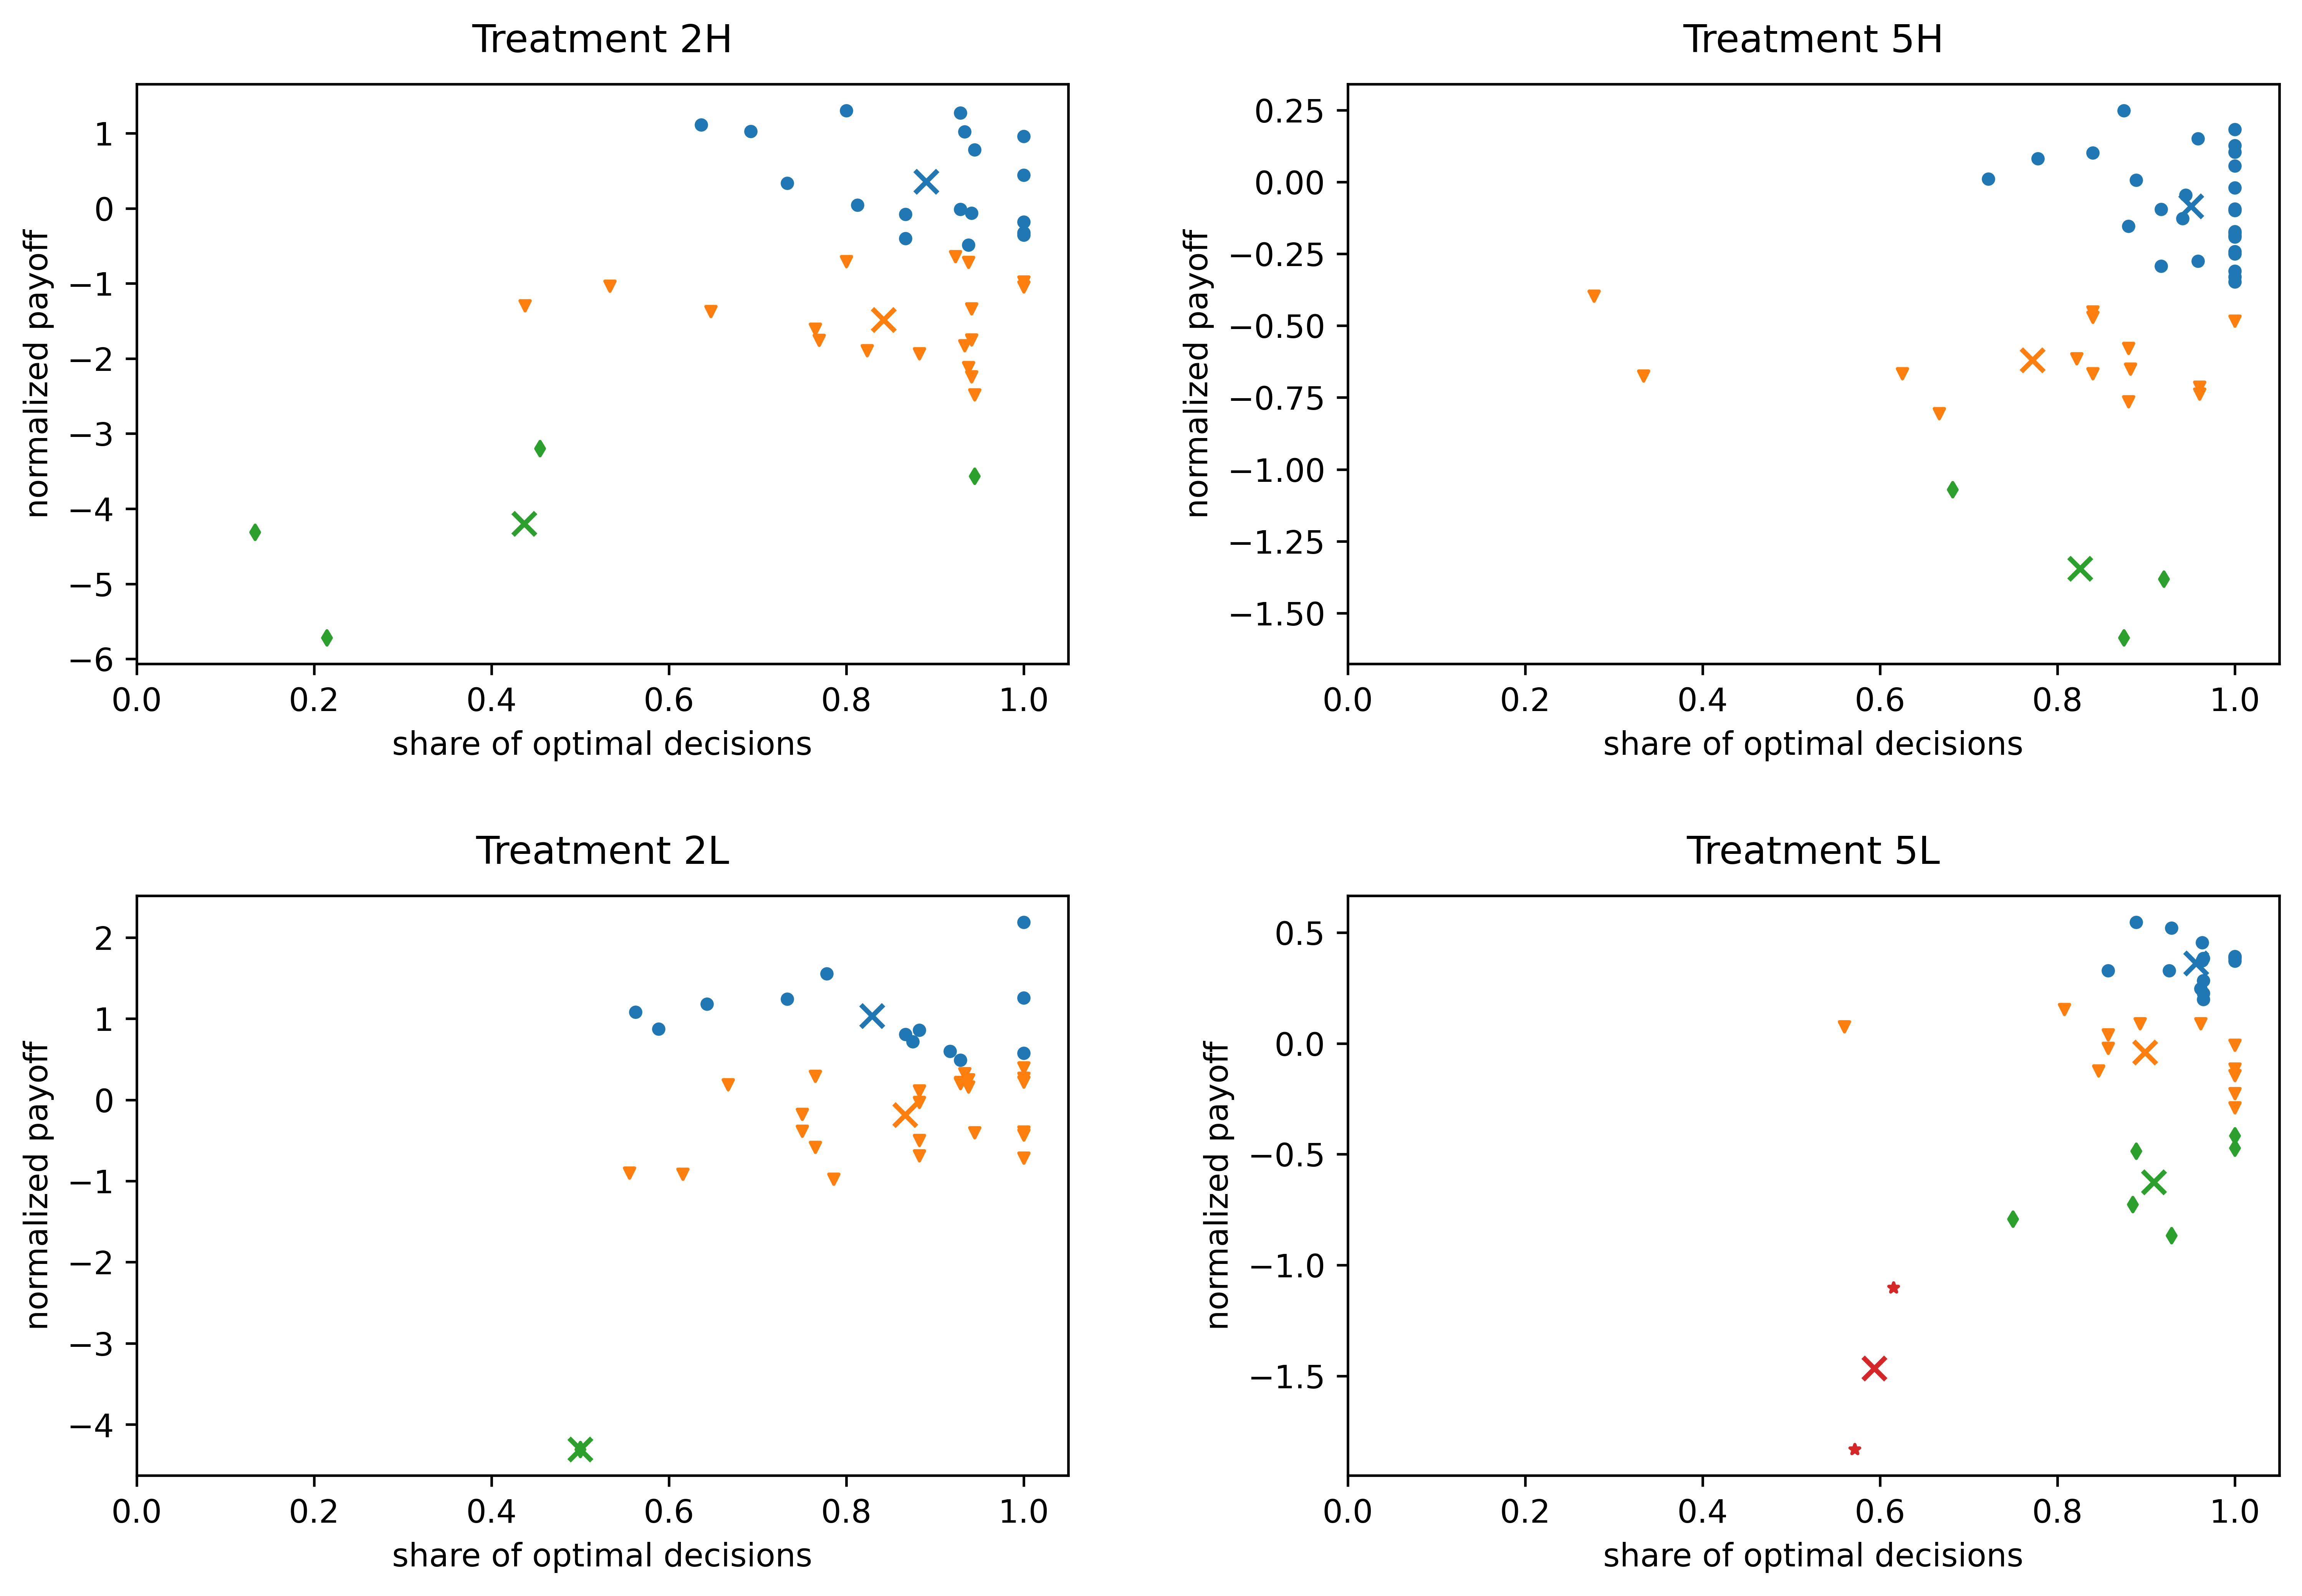

In [102]:
plt.figure(figsize=(12, 8), dpi=600)
plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.subplot(221)
plotCluster(2, 0.019, 3)
plt.subplot(223)
plotCluster(2, 0.009, 3)
plt.subplot(222)
plotCluster(5, 0.019, 3)
plt.subplot(224)
plotCluster(5, 0.009, 4)

##### Normalised paydiff distribution

In [38]:
def plotPaynormDist(n, b):
    tmpdf = copy.deepcopy(df_cluster[(df_cluster["n"] == n) & (df_cluster["b"] == b)])
    if n == 2:
        if b == 0.019:
            tmpdf["paydiff_norm"] /= 5.88
        elif b == 0.009:
            tmpdf["paydiff_norm"] /= 7.26
    elif n == 5:
        if b == 0.019:
            tmpdf["paydiff_norm"] /= 1.265
        elif b == 0.009:
            tmpdf["paydiff_norm"] /= 1.445
    sns.histplot(tmpdf["paydiff_norm"], bins=np.arange(-1.3, 0.5, 0.1), stat="density")
    plt.xlabel("actual/theoretical ratio")
    plt.ylim(0, 3.5)
    plt.title(str(n) + ("H" if b == 0.019 else "L"))

Text(0.5, 0.98, 'Distribution of normalised payoffs')

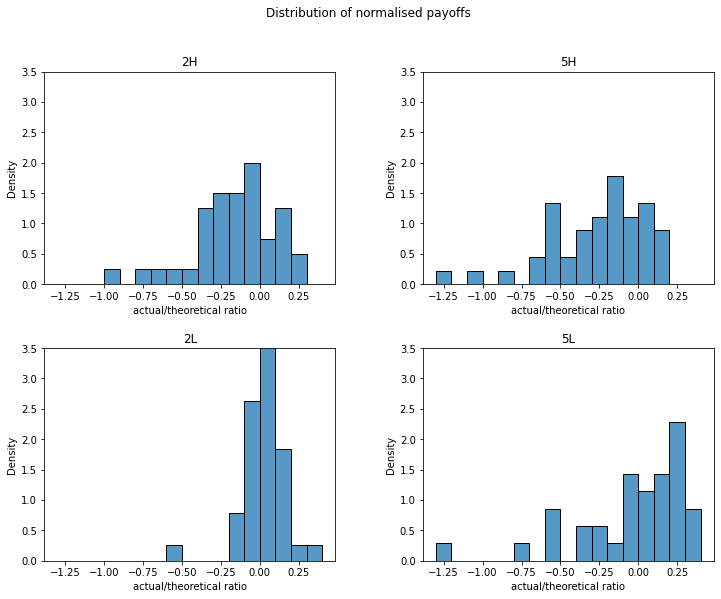

In [39]:
plt.figure(figsize=(12, 9))
plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.subplot(2, 2, 1)
plotPaynormDist(2, 0.019)
plt.subplot(2, 2, 3)
plotPaynormDist(2, 0.009)
plt.subplot(2, 2, 2)
plotPaynormDist(5, 0.019)
plt.subplot(2, 2, 4)
plotPaynormDist(5, 0.009)
plt.suptitle("Distribution of normalised payoffs")

##### Percentage paydiff distribution

In [20]:
def plotPaypctDist(n, b):
    tmpdf_h = copy.deepcopy(df_h_cluster[(df_h_cluster["n"] == n) & (df_h_cluster["b"] == b)])
    tmpdf_d = copy.deepcopy(df_d_cluster[(df_d_cluster["n"] == n) & (df_d_cluster["b"] == b)])
    
    sns.histplot(np.clip(tmpdf_h["paydiff_pct"], -0.1, 2.1), bins=np.arange(-0.1, 2.2, 0.1), color="C0", edgecolor=None, alpha=0.4, stat="probability", label="Honolulu") 
    all_median = np.quantile(tmpdf_h["paydiff_pct"], 0.5)
    bottom_average = np.average(tmpdf_h[(tmpdf_h["paydiff_pct"] <= all_median) & (tmpdf_h["paydiff_pct"] >= 0)]["paydiff_pct"])
    top_average = np.average(tmpdf_h[(tmpdf_h["paydiff_pct"] > all_median) & (tmpdf_h["paydiff_pct"] <= 2)]["paydiff_pct"])
    plt.axvline(all_median, color="C0", linestyle="--", linewidth=1, label="Honolulu median")
    plt.scatter([bottom_average, top_average], [0.01, 0.01], color="C0", marker="$\\downarrow$", s=80, label="Honolulu bottom/top average")
    plt.annotate("Honolulu:\nmedian = {:.1%}\nbottom average = {:.1%}\ntop average = {:.1%}".format(all_median, bottom_average, top_average), xy=(1.3, 0.4), xytext=(1.3, 0.3), color="C0")

    sns.histplot(np.clip(tmpdf_d["paydiff_pct"], -0.1, 2.1), bins=np.arange(-0.1, 2.2, 0.1), color="C3", element="step", fill=False, stat="probability", label="Dutch")
    all_median = np.quantile(tmpdf_d["paydiff_pct"], 0.5)
    bottom_average = np.average(tmpdf_d[(tmpdf_d["paydiff_pct"] <= all_median) & (tmpdf_d["paydiff_pct"] >= 0)]["paydiff_pct"])
    top_average = np.average(tmpdf_d[(tmpdf_d["paydiff_pct"] > all_median) & (tmpdf_d["paydiff_pct"] <= 2)]["paydiff_pct"])
    plt.axvline(all_median, color="C3", linestyle="-.", linewidth=1, label="Dutch median")
    plt.scatter([bottom_average, top_average], [0.01, 0.01], color="C3", marker="$\\twoheaddownarrow$", s=80, label="Dutch bottom/top average")
    plt.annotate("Dutch:\nmedian = {:.1%}\nbottom average = {:.1%}\ntop average = {:.1%}".format(all_median, bottom_average, top_average), xy=(1.3, 0.4), xytext=(1.3, 0.2), color="C3")

    plt.xticks(ticks=[0, 0.5, 1, 1.5, 2], labels=["$\\leq0\\%$", "$50\\%$", "$100\\%$", "$150\\%$", "$\\geq200\\%$"])
    plt.xlabel("percent payoff")
    plt.ylim(0, 0.40)
    plt.title(str(n) + ("H" if b == 0.019 else "L"))

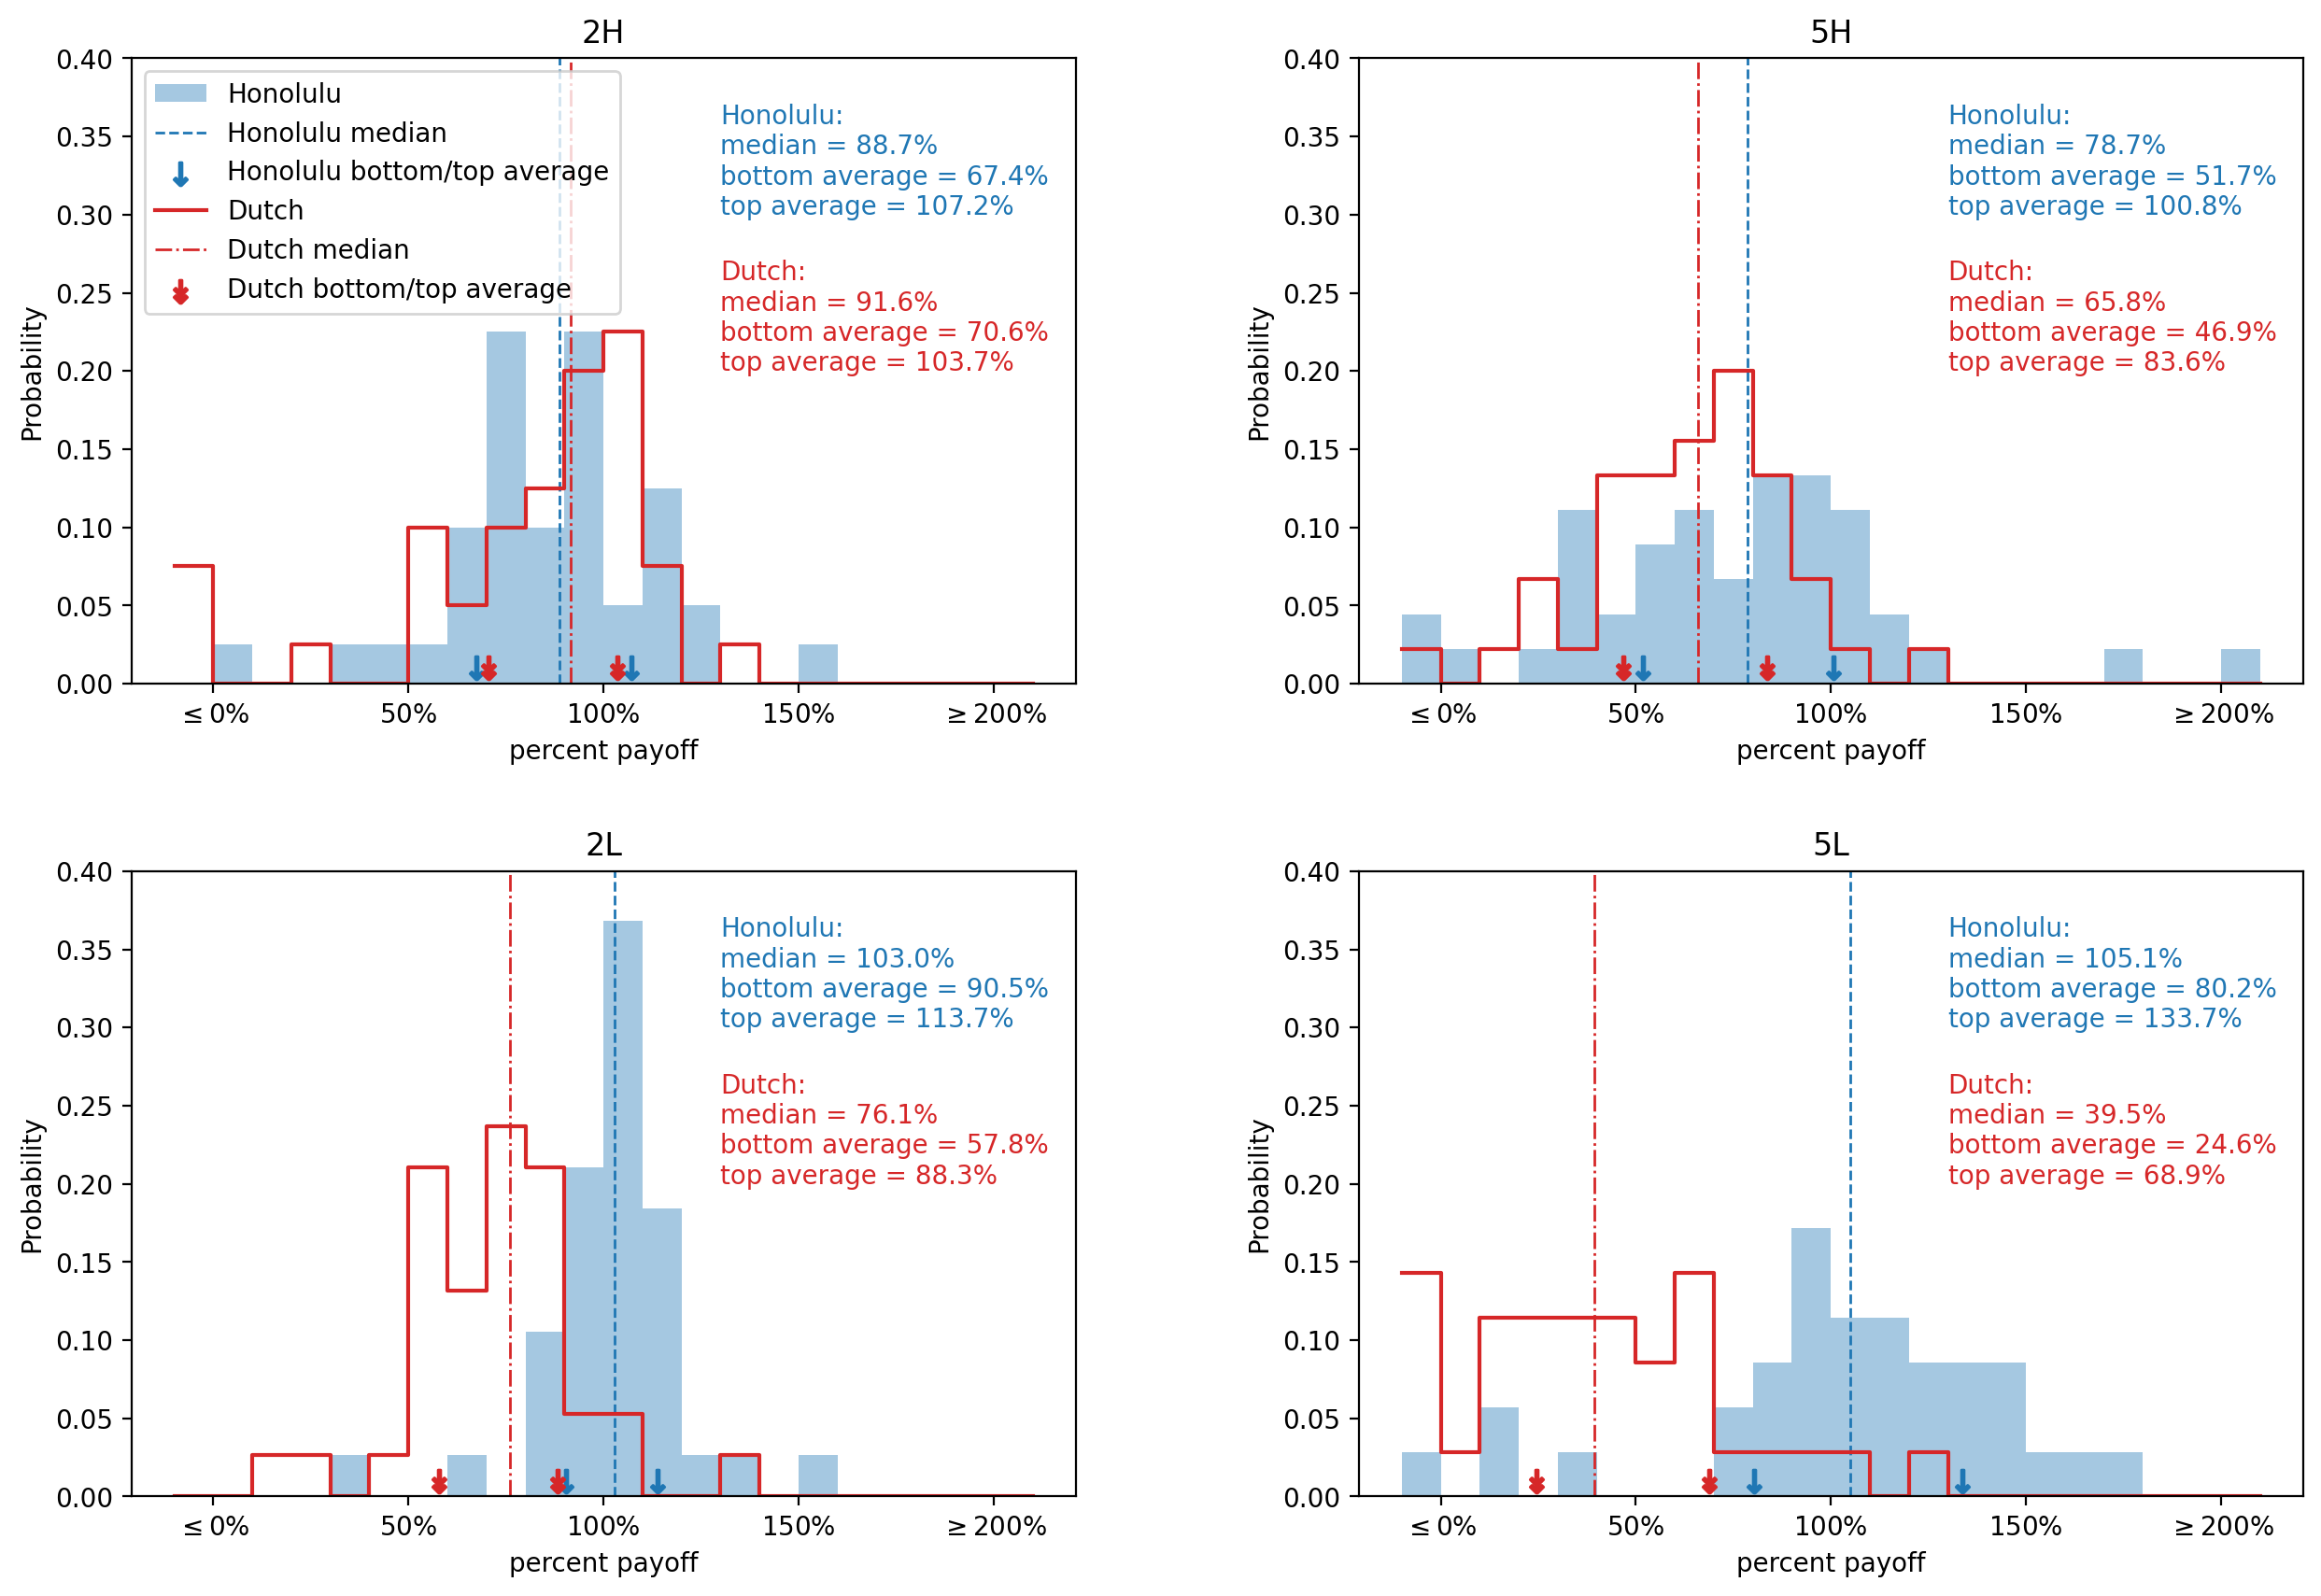

In [27]:
plt.figure(figsize=(15, 10), dpi=200)
plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.subplot(2, 2, 1)
plotPaypctDist(2, 0.019)

#get handles and labels
handles, labels = plt.gca().get_legend_handles_labels()
#specify order of items in legend
order = [5, 0, 1, 2, 3, 4]
#add legend to plot
plt.legend([handles[idx] for idx in order], [labels[idx] for idx in order], loc="upper left")

plt.subplot(2, 2, 3)
plotPaypctDist(2, 0.009)
plt.subplot(2, 2, 2)
plotPaypctDist(5, 0.019)
plt.subplot(2, 2, 4)
plotPaypctDist(5, 0.009)